In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [55]:
df =pd.read_csv('/content/wfp_food_prices_global_2026.csv')
df.head()

,countryiso3,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
0,AFG,2026-01-15,Badakhshan,Argo,Badakhshan,3690,37.04,70.46,cereals and tubers,Bread,55,KG,aggregate,Retail,AFN,77.00,1.16
1,AFG,2026-01-15,Badakhshan,Argo,Badakhshan,3690,37.04,70.46,cereals and tubers,Rice (high quality),247,KG,aggregate,Retail,AFN,127.93,1.93
2,AFG,2026-01-15,Badakhshan,Argo,Badakhshan,3690,37.04,70.46,cereals and tubers,Rice (low quality),145,KG,aggregate,Retail,AFN,48.70,0.73
3,AFG,2026-01-15,Badakhshan,Argo,Badakhshan,3690,37.04,70.46,cereals and tubers,Wheat,84,KG,aggregate,Retail,AFN,26.74,0.40
4,AFG,2026-01-15,Badakhshan,Argo,Badakhshan,3690,37.04,70.46,cereals and tubers,Wheat flour (high quality),178,KG,aggregate,Retail,AFN,31.26,0.47


In [56]:
df.tail()

,countryiso3,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
85284,ZMB,2026-01-15,Luapula,Mansa,Mansa,389,-11.20,28.88,miscellaneous food,Salt,185,KG,actual,Retail,ZMW,12.0,0.60
85285,ZMB,2026-01-15,Luapula,Milengi,Milenge,1449,-11.96,29.49,miscellaneous food,Salt,185,KG,actual,Retail,ZMW,11.0,0.55
85286,ZMB,2026-01-15,Lusaka,Luangwa,Luangwa Zaro Market,383,-15.62,30.41,miscellaneous food,Salt,185,KG,actual,Retail,ZMW,10.0,0.50
85287,ZMB,2026-01-15,Muchiga,Mpika,Mpika,397,-11.84,31.45,miscellaneous food,Salt,185,KG,actual,Retail,ZMW,10.0,0.50
85288,ZMB,2026-01-15,Muchiga,Nakonde,Nakonde,1454,-9.33,32.77,miscellaneous food,Salt,185,KG,actual,Retail,ZMW,15.0,0.75


In [57]:
df.shape

(85289, 17)

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85289 entries, 0 to 85288
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   countryiso3   85289 non-null  object 
 1   date          85289 non-null  object 
 2   admin1        85260 non-null  object 
 3   admin2        85260 non-null  object 
 4   market        85289 non-null  object 
 5   market_id     85289 non-null  int64  
 6   latitude      85260 non-null  float64
 7   longitude     85260 non-null  float64
 8   category      85289 non-null  object 
 9   commodity     85289 non-null  object 
 10  commodity_id  85289 non-null  int64  
 11  unit          85289 non-null  object 
 12  priceflag     85289 non-null  object 
 13  pricetype     85289 non-null  object 
 14  currency      85289 non-null  object 
 15  price         85289 non-null  float64
 16  usdprice      84949 non-null  float64
dtypes: float64(4), int64(2), object(11)
memory usage: 11.1+ MB


In [59]:
df.describe()

,market_id,latitude,longitude,commodity_id,price,usdprice
count,85289.000000,85260.000000,85260.000000,85289.000000,8.528900e+04,84949.000000
mean,2896.821173,17.154274,42.368389,335.765128,2.160659e+04,84.028117
std,2179.025312,16.023934,39.051818,307.131565,2.175940e+05,1168.169360
min,80.000000,-30.400000,-90.520000,50.000000,1.400000e-01,0.031000
25%,1548.000000,7.220000,17.960000,97.000000,1.766700e+02,0.750000
50%,2354.000000,13.560000,36.040000,225.000000,1.044000e+03,1.710000
75%,3912.000000,32.890000,49.130000,467.000000,7.667000e+03,9.610000
max,11721.000000,51.500000,140.700000,1349.000000,1.900000e+07,53535.350000


In [60]:
df.columns

Index(['countryiso3', 'date', 'admin1', 'admin2', 'market', 'market_id',
       'latitude', 'longitude', 'category', 'commodity', 'commodity_id',
       'unit', 'priceflag', 'pricetype', 'currency', 'price', 'usdprice'],
      dtype='object')

In [61]:
df.dtypes

,0
countryiso3,object
date,object
admin1,object
admin2,object
market,object
market_id,int64
latitude,float64
longitude,float64
category,object
commodity,object


In [62]:
# Separate columns by data type
numerical_cols = df.select_dtypes(include=['int64', 'float64'])
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print("numerical_cols",numerical_cols )
print("\n categorical_cols",categorical_cols)

numerical_cols        market_id  latitude  longitude  commodity_id   price  usdprice
0           3690     37.04      70.46            55   77.00      1.16
1           3690     37.04      70.46           247  127.93      1.93
2           3690     37.04      70.46           145   48.70      0.73
3           3690     37.04      70.46            84   26.74      0.40
4           3690     37.04      70.46           178   31.26      0.47
...          ...       ...        ...           ...     ...       ...
85284        389    -11.20      28.88           185   12.00      0.60
85285       1449    -11.96      29.49           185   11.00      0.55
85286        383    -15.62      30.41           185   10.00      0.50
85287        397    -11.84      31.45           185   10.00      0.50
85288       1454     -9.33      32.77           185   15.00      0.75

[85289 rows x 6 columns]

 categorical_cols ['countryiso3', 'date', 'admin1', 'admin2', 'market', 'category', 'commodity', 'unit', 'priceflag', 

In [63]:
df.nunique()

,0
countryiso3,60
date,6
admin1,559
admin2,1279
market,1730
market_id,1730
latitude,1371
longitude,1529
category,8
commodity,541


In [64]:
df.isna().sum()

,0
countryiso3,0
date,0
admin1,29
admin2,29
market,0
market_id,0
latitude,29
longitude,29
category,0
commodity,0


In [65]:
df.duplicated().sum()

np.int64(0)

In [66]:
df=df.dropna()

In [67]:
df.shape

(84920, 17)

In [68]:
df.nunique()

,0
countryiso3,59
date,6
admin1,554
admin2,1272
market,1722
market_id,1722
latitude,1367
longitude,1523
category,8
commodity,539


In [69]:
df['date'] = pd.to_datetime(df['date'])

### **Analysis**

In [70]:
country_counts=df['countryiso3'].value_counts().sort_values(ascending=False).head(15)
country_counts

,count
countryiso3,
SYR,14380
PHL,7771
BEN,5484
MWI,4168
COD,2918
BDI,2910
KHM,2846
UKR,2440
IRQ,2356


<Axes: title={'center': 'Top 15 country by number of record '}, xlabel='number of record', ylabel='country'>

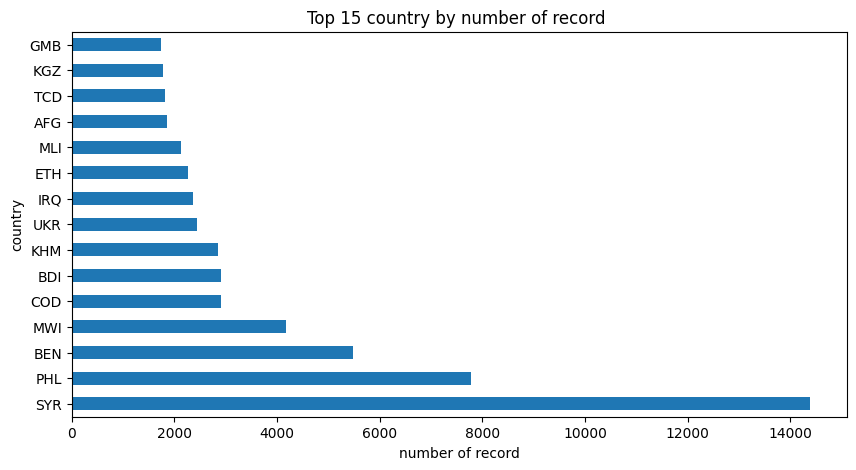

In [71]:
plt.figure(figsize=(10,5))
country_counts.plot(kind='barh',title='Top 15 country by number of record ',xlabel='number of record',ylabel='country')

In [72]:
Categories_count = df['category'].value_counts()
Categories_count

,count
category,
cereals and tubers,23285
vegetables and fruits,17673
"meat, fish and eggs",12027
non-food,10722
pulses and nuts,8742
miscellaneous food,5507
oil and fats,4704
milk and dairy,2260


<Axes: title={'center': 'Number of records bycategory'}, xlabel='number of records', ylabel='category'>

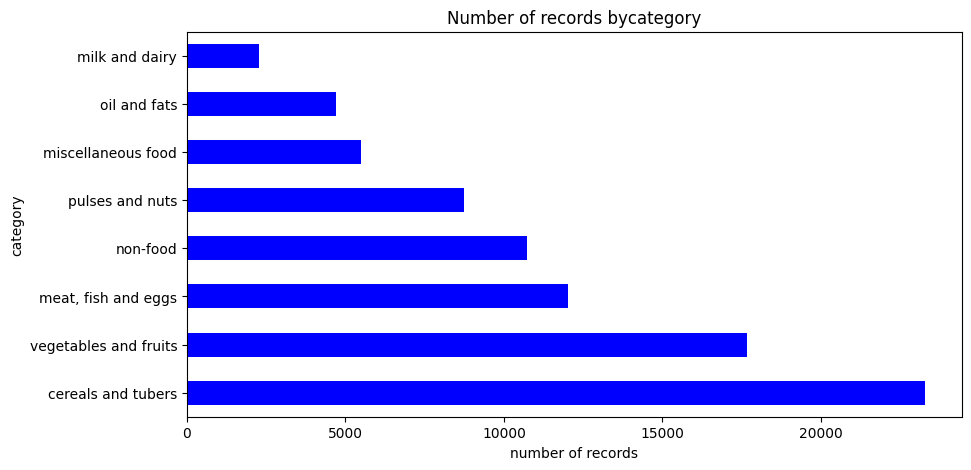

In [73]:
plt.figure(figsize=(10,5))
Categories_count.plot(kind ='barh',color='b',ylabel='category',xlabel='number of records',title="Number of records bycategory")


In [74]:
commodity_count=df['commodity'].value_counts().sort_values(ascending=False).head(15)
commodity_count

,count
commodity,
Sugar,1862
Tomatoes,1778
Salt,1714
Onions,1547
Oil (vegetable),1518
Eggs,1470
Wheat flour,1355
Oil (palm),1269
Rice (imported),1159


<Axes: title={'center': 'Top 15 commodity by number of records'}, xlabel='Number of records', ylabel='commodity'>

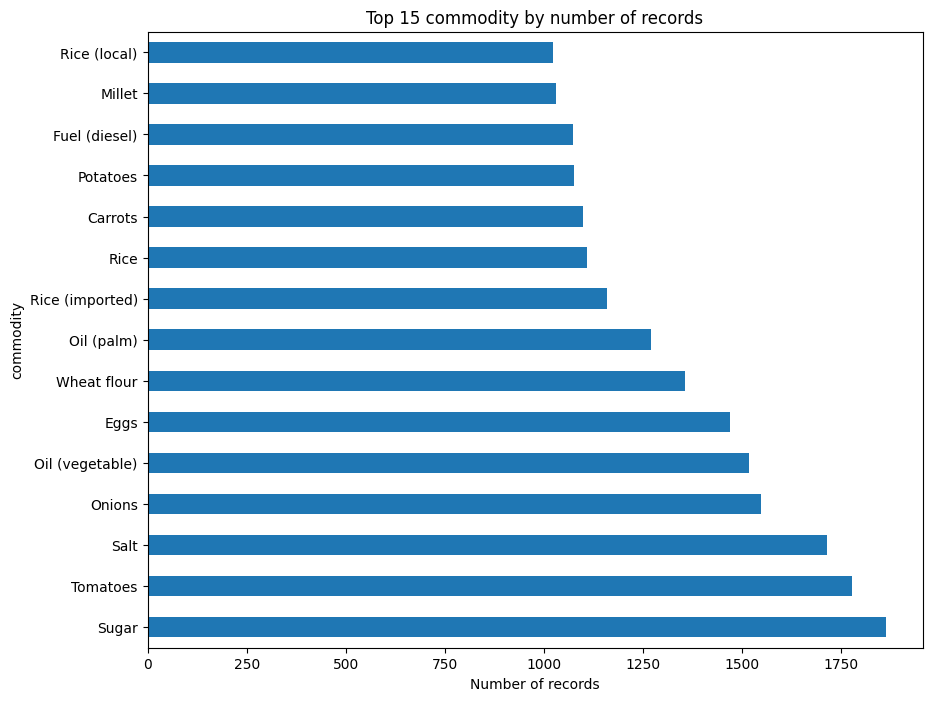

In [75]:
plt.figure(figsize=(10,8))
commodity_count.plot(kind='barh',xlabel='Number of records',ylabel='commodity',title='Top 15 commodity by number of records')

<Axes: title={'center': 'Commodity Category Distribution'}, ylabel='count'>

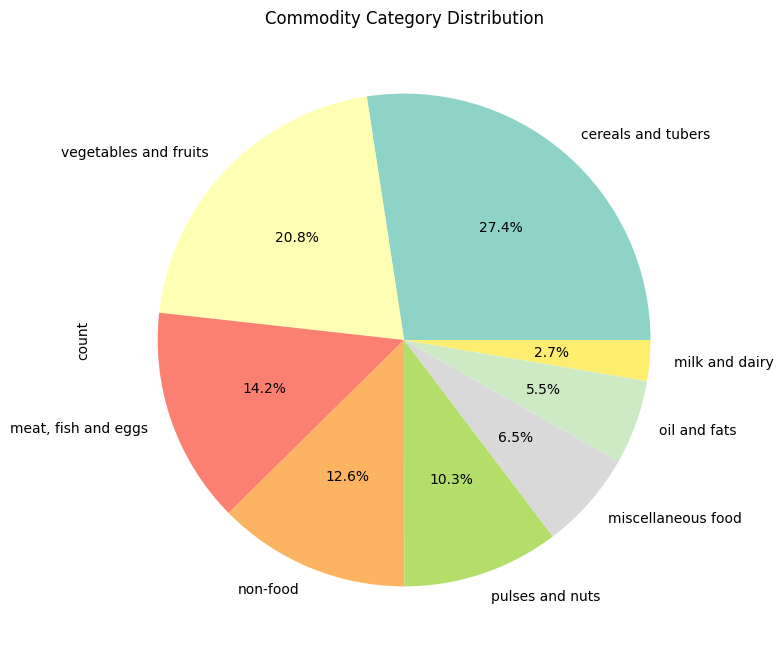

In [76]:
plt.figure(figsize=(10,8))
Categories_count.plot(kind='pie',title='Commodity Category Distribution', autopct='%1.1f%%', cmap='Set3')

Text(0, 0.5, 'Frequency')

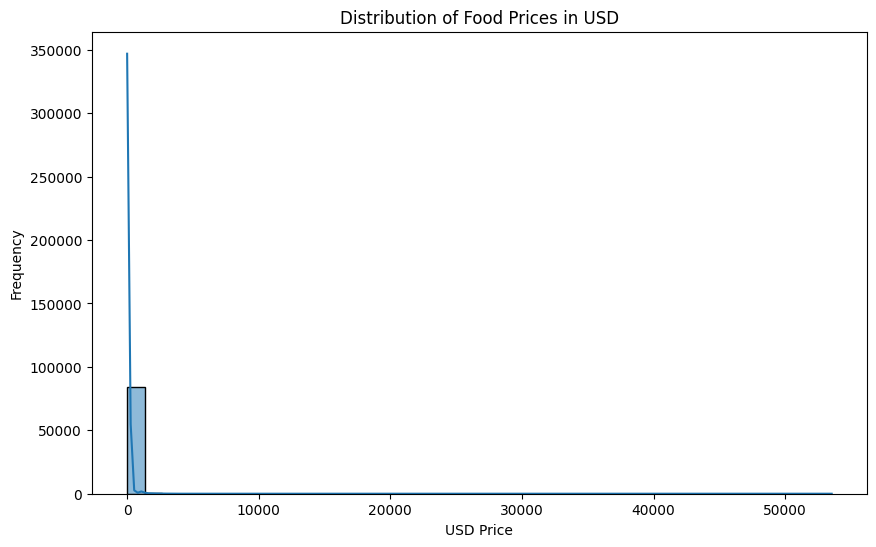

In [77]:
plt.figure(figsize=(10, 6))

sns.histplot(data=df, x="usdprice", bins=40,kde=True)
plt.title("Distribution of Food Prices in USD")
plt.xlabel("USD Price")
plt.ylabel("Frequency")

Text(0.5, 1.0, 'Distribution of usdPrice by category')

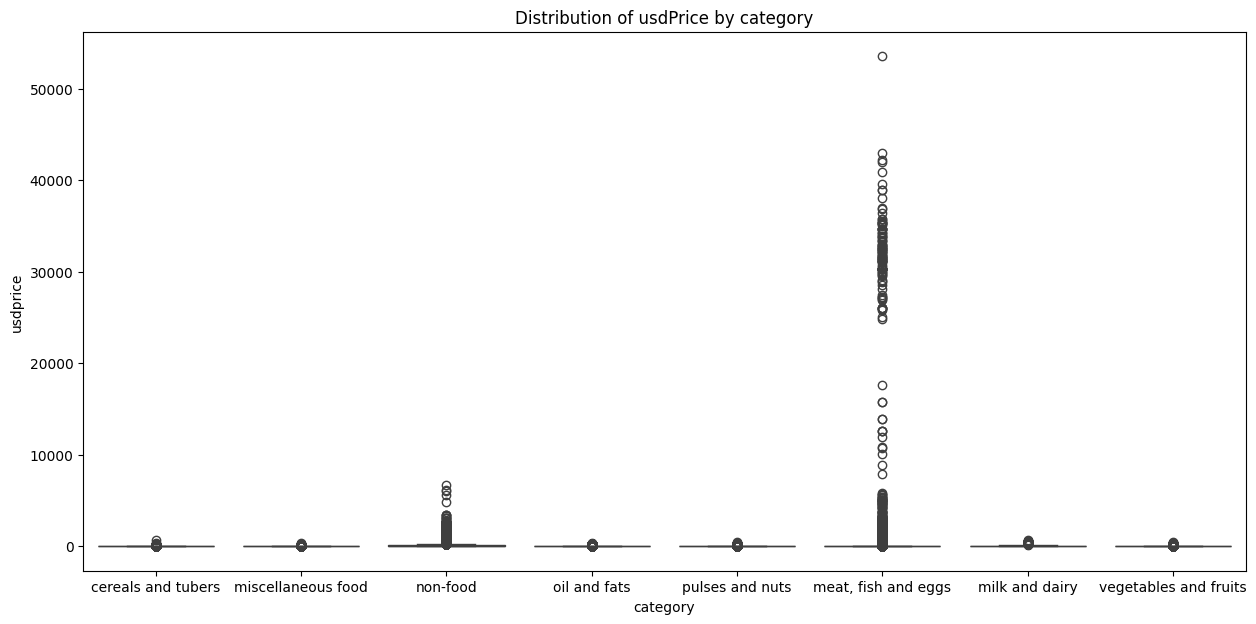

In [78]:
plt.figure(figsize=(15,7))
sns.boxplot(data=df,x='category',y='usdprice')
plt.title("Distribution of usdPrice by category")

In [79]:
average_category_prices = df.groupby('category')['usdprice'].mean().reset_index()
average_category_prices

,category,usdprice
0,cereals and tubers,12.733640
1,"meat, fish and eggs",402.239246
2,milk and dairy,57.061336
3,miscellaneous food,9.834565
4,non-food,115.475114
5,oil and fats,18.947861
6,pulses and nuts,24.444227
7,vegetables and fruits,15.830117


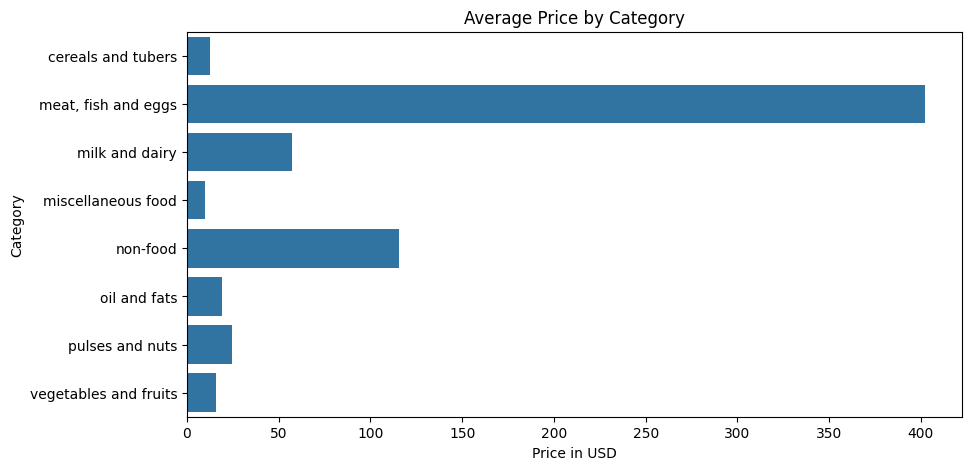

In [80]:
plt.figure(figsize=(10, 5))
sns.barplot(data=average_category_prices, x='usdprice', y='category')
plt.title('Average Price by Category')
plt.xlabel('Price in USD')
plt.ylabel('Category')
plt.show()

In [81]:
median_category_prices=df.groupby('category')['usdprice'].median().sort_values(ascending=True)
median_category_prices

,usdprice
category,
cereals and tubers,0.85
miscellaneous food,1.03
vegetables and fruits,1.23
pulses and nuts,1.58
oil and fats,2.29
milk and dairy,4.13
"meat, fish and eggs",5.22
non-food,18.91


<Axes: title={'center': 'Median price by category'}, ylabel='category'>

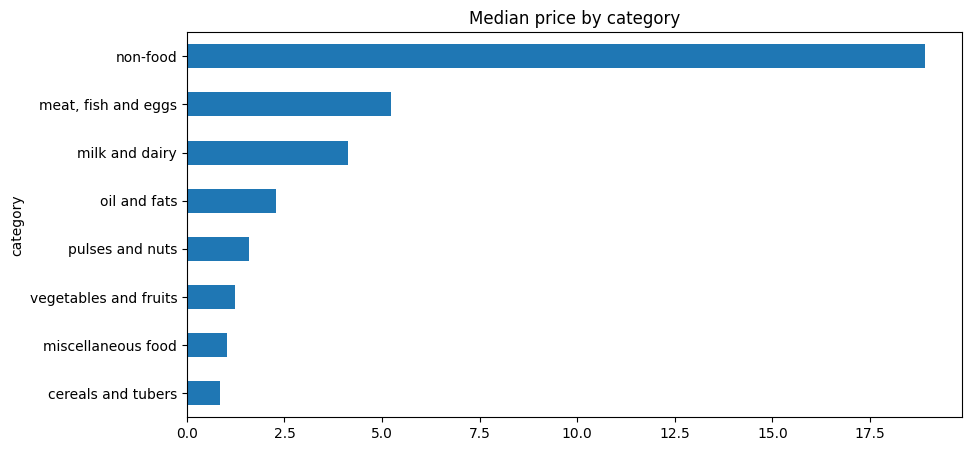

In [82]:
plt.figure(figsize=(10,5))
median_category_prices.plot(kind='barh',x='median USD price',y='category',title='Median price by category')

In [83]:
country_price = df.groupby('countryiso3')['usdprice'].mean().sort_values(ascending=False).head(15)
country_price

,usdprice
countryiso3,
SYR,397.372920
SSD,341.823014
SOM,260.877351
YEM,84.750804
TZA,72.241020
ETH,68.702809
IRN,47.718281
MRT,37.881794
GTM,32.134583


/tmp/ipykernel_1029/1711043291.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




Text(0, 0.5, 'Average price')

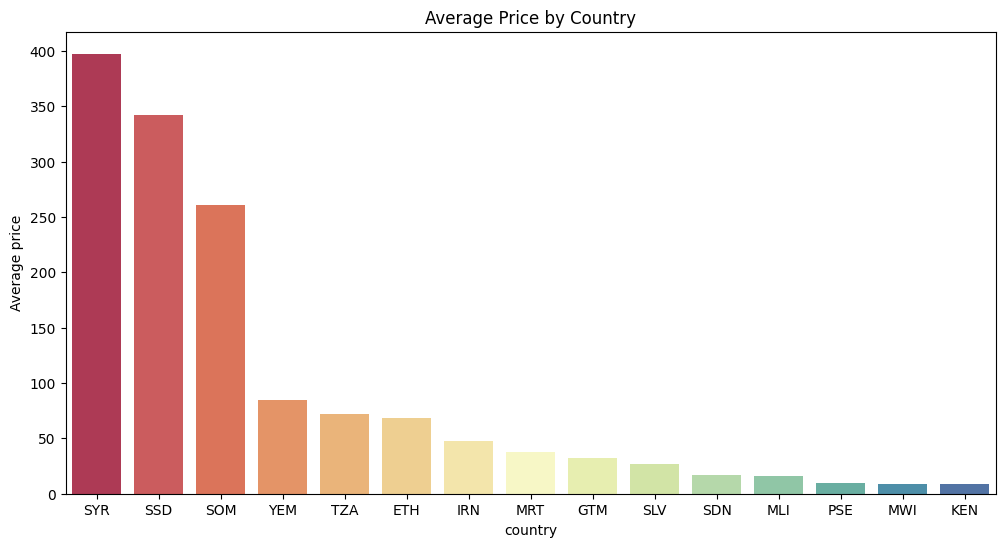

In [84]:
plt.figure(figsize=(12,6))

sns.barplot(x=country_price.index, y=country_price.values, palette='Spectral')
plt.title('Average Price by Country')
plt.xlabel("country")
plt.ylabel("Average price")

In [85]:
monthly = df.groupby([df['date'].dt.to_period('M'),'category'])['usdprice'].mean().unstack()
monthly

category,cereals and tubers,"meat, fish and eggs",milk and dairy,miscellaneous food,non-food,oil and fats,pulses and nuts,vegetables and fruits
date,,,,,,,,
2026-01,10.396344,100.488748,44.823900,7.335774,92.980393,13.721786,19.418570,11.236255
2026-02,11.391533,100.224286,52.025570,8.782726,101.368320,15.902042,21.273910,12.655653
2026-03,12.481650,672.645949,57.307782,9.852260,123.686182,18.602509,23.824456,14.318403
2026-04,36.539235,2866.361405,109.877716,22.838420,215.391999,55.951419,68.380193,61.694937
2026-05,116.786000,702.412500,99.933333,152.905000,106.177500,240.220000,395.167500,104.896667
2026-12,17.498442,90.012749,52.630000,14.321942,73.775395,51.565278,39.693839,20.909014


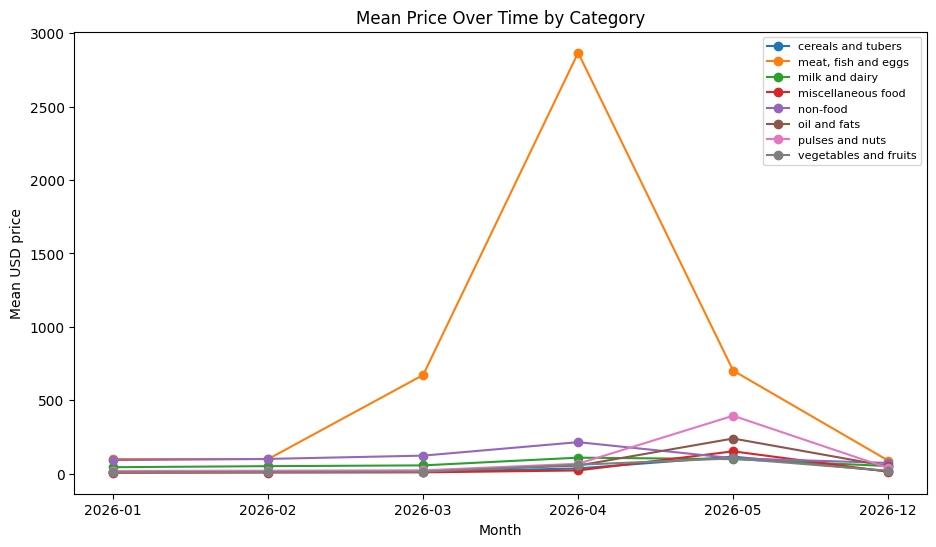

In [86]:
plt.figure(figsize=(11,6))
for col in monthly.columns:
    plt.plot(monthly.index.astype(str), monthly[col], marker='o', label=col)
plt.title('Mean Price Over Time by Category')
plt.xlabel('Month')
plt.ylabel('Mean USD price')
plt.legend(fontsize=8,bbox_to_anchor=(1,1))

In [87]:
kg = df[df['unit']=='KG']
kg.shape

(60511, 17)

In [88]:
monthly = kg.groupby([kg['date'].dt.to_period('M'),'category'])['usdprice'].median().unstack()
monthly

category,cereals and tubers,"meat, fish and eggs",milk and dairy,miscellaneous food,non-food,oil and fats,pulses and nuts,vegetables and fruits
date,,,,,,,,
2026-01,0.75,4.970,8.975,1.055,0.580,2.960,1.360,1.29
2026-02,0.75,5.200,49.990,1.030,0.580,3.505,1.420,1.08
2026-03,0.75,5.040,67.820,0.990,0.580,3.930,1.440,1.08
2026-04,1.40,48.210,73.160,4.020,0.235,1.850,10.735,59.16
2026-05,86.48,1105.025,116.270,98.495,NaN,NaN,NaN,88.88
2026-12,20.81,66.055,27.490,17.180,NaN,NaN,40.150,19.09


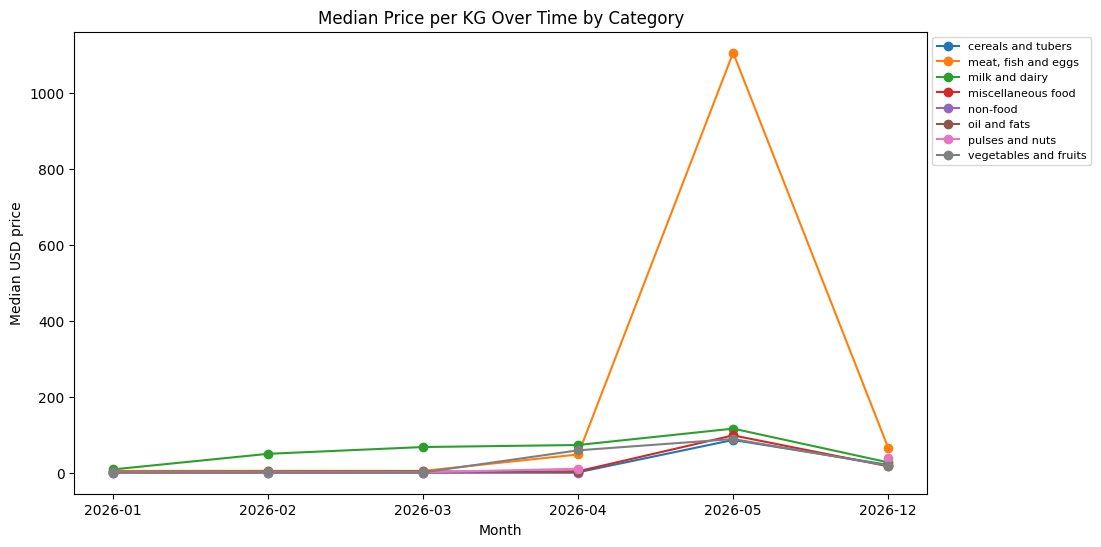

In [89]:
plt.figure(figsize=(11,6))
for col in monthly.columns:
    plt.plot(monthly.index.astype(str), monthly[col], marker='o', label=col)
plt.title('Median Price per KG Over Time by Category')
plt.xlabel('Month')
plt.ylabel('Median USD price')
plt.legend(fontsize=8,bbox_to_anchor=(1,1))

In [90]:
pt = kg.groupby(['category','pricetype'])['usdprice'].median().unstack()
pt

pricetype,Retail,Wholesale
category,,
cereals and tubers,0.770,0.610
"meat, fish and eggs",5.330,2.300
milk and dairy,62.070,NaN
miscellaneous food,1.100,0.605
non-food,0.580,NaN
oil and fats,3.195,NaN
pulses and nuts,1.490,1.620
vegetables and fruits,1.310,0.620


<Axes: title={'center': 'Commodity Category Distribution'}, ylabel='Retail'>

<Figure size 1500x800 with 0 Axes>

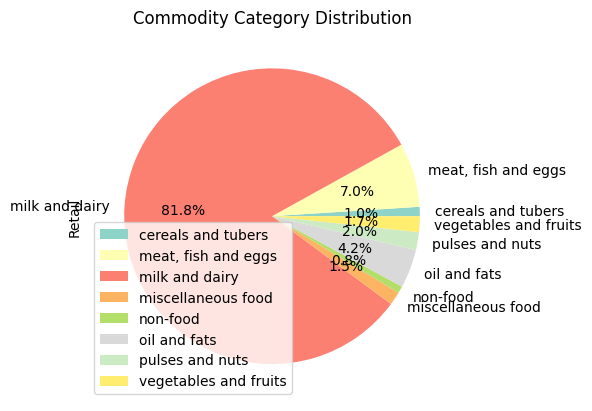

In [91]:
plt.figure(figsize=(15,8))
pt.plot(kind='pie',y='Retail',title='Commodity Category Distribution', autopct='%1.1f%%', cmap='Set3',legend='left')

<Axes: title={'center': 'Retail vs Wholesale Median Price per KG'}, xlabel='Median USD price', ylabel='category'>

<Figure size 1000x600 with 0 Axes>

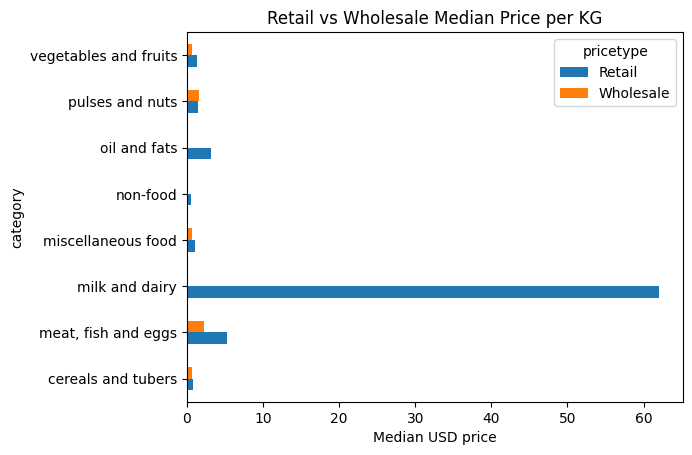

In [92]:
plt.figure(figsize=(10,6))
pt.plot(kind='barh',title='Retail vs Wholesale Median Price per KG',xlabel='Median USD price',ylabel='category')

Text(0.5, 1.0, 'Market Locations Colored by Price')

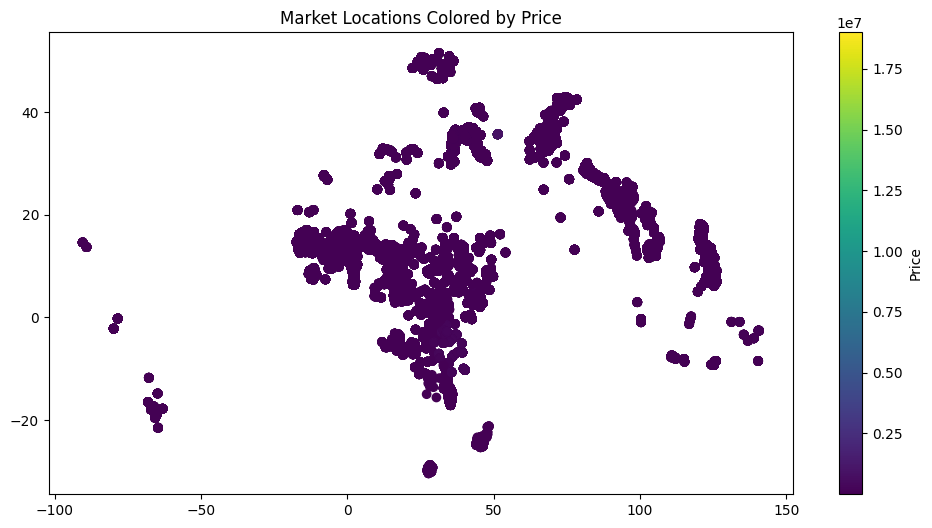

In [93]:
plt.figure(figsize=(12,6))
scatter=plt.scatter(df['longitude'], df['latitude'] , c =df['price'])
plt.colorbar(scatter, label='Price')
plt.title('Market Locations Colored by Price')



/usr/local/lib/python3.13/dist-packages/seaborn/axisgrid.py:1513: UserWarning:

Ignoring `palette` because no `hue` variable has been assigned.

/usr/local/lib/python3.13/dist-packages/seaborn/axisgrid.py:1513: UserWarning:

Ignoring `palette` because no `hue` variable has been assigned.

/usr/local/lib/python3.13/dist-packages/seaborn/axisgrid.py:1513: UserWarning:

Ignoring `palette` because no `hue` variable has been assigned.

/usr/local/lib/python3.13/dist-packages/seaborn/axisgrid.py:1615: UserWarning:

Ignoring `palette` because no `hue` variable has been assigned.

/usr/local/lib/python3.13/dist-packages/seaborn/axisgrid.py:1615: UserWarning:

Ignoring `palette` because no `hue` variable has been assigned.

/usr/local/lib/python3.13/dist-packages/seaborn/axisgrid.py:1615: UserWarning:

Ignoring `palette` because no `hue` variable has been assigned.

/usr/local/lib/python3.13/dist-packages/seaborn/axisgrid.py:1615: UserWarning:

Ignoring `palette` because no `hue` variable has b

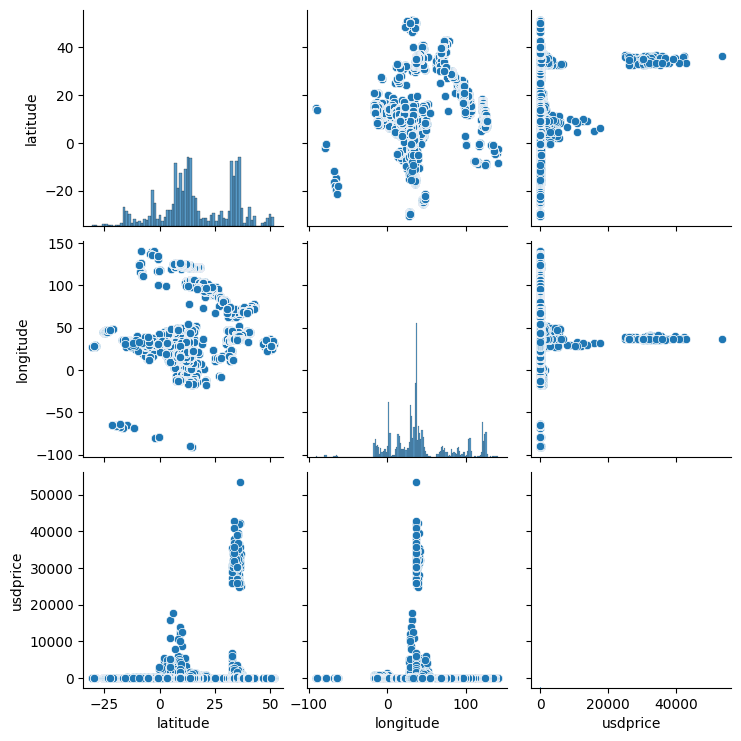

In [94]:
cols = ['latitude','longitude','usdprice']
sns.pairplot(df[cols],palette='Set1')

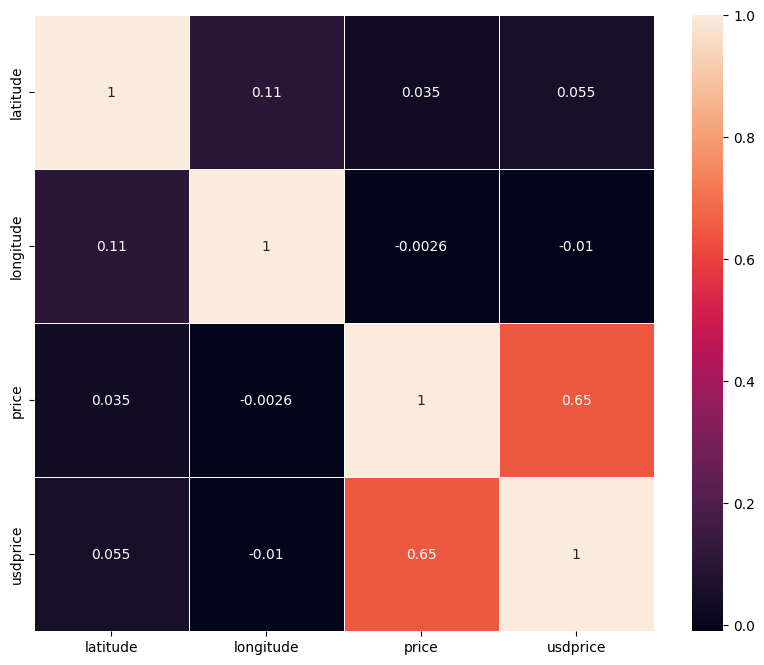

In [95]:
numerical_cols = df[['latitude','longitude','price','usdprice']]
plt.figure(figsize=(10,8))
sns.heatmap(numerical_cols.corr(),annot=True, linewidths=0.5)
plt.show()

In [96]:
coverage = df.groupby('countryiso3').agg(
    records=('usdprice','count'),
    markets=('market','nunique'),
    commodities=('commodity','nunique'),
    months=('date', lambda s: s.dt.to_period('M').nunique())
).sort_values('records',ascending=False)
coverage

,records,markets,commodities,months
countryiso3,,,,
SYR,14380,73,46,5
PHL,7771,83,59,3
BEN,5484,50,52,3
MWI,4168,96,26,4
COD,2918,106,23,2
BDI,2910,70,15,3
KHM,2846,30,46,3
UKR,2440,23,37,3
IRQ,2356,19,48,4


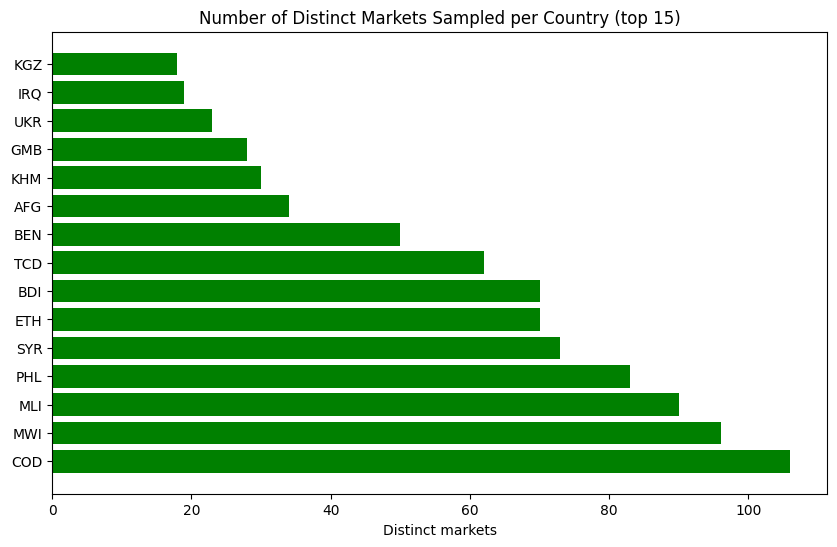

In [97]:
plt.figure(figsize=(10,6))
top15 = coverage.head(15).sort_values('markets',ascending=False)
plt.barh(top15.index, top15['markets'], color='green')
plt.title('Number of Distinct Markets Sampled per Country (top 15)')
plt.xlabel('Distinct markets')
plt.show()

Text(0.5, 1.0, 'Median USD Price by Commodity and Month')

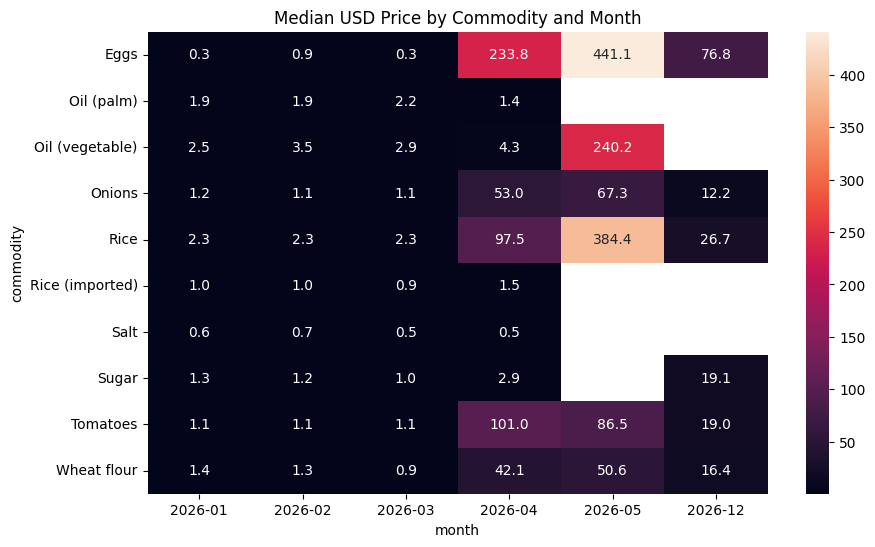

In [98]:
top10 = df['commodity'].value_counts().head(10).index
heat_df = df[df['commodity'].isin(top10)].copy()
heat_df['month'] = heat_df['date'].dt.to_period('M').astype(str)

pivot = pd.pivot_table(
    heat_df,
    values='usdprice',
    index='commodity',
    columns='month',
    aggfunc='median'
)
plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt='.1f')
plt.title('Median USD Price by Commodity and Month')

In [99]:
pip install plotly

In [100]:
 pip install --upgrade nbformat

In [101]:
import plotly.express as px
fig = px.bar(
    average_category_prices.reset_index(),
    x="usdprice",
    y="category",
    orientation="h",
    title="Average USD Price by Food Category"
)

fig.update_layout(
    xaxis_title="Average USD Price",
    yaxis_title="Food Category"
)

fig.show()

In [102]:
fig = px.scatter_geo(
    df,
    lat='latitude',
    lon='longitude',
    hover_name='market',
    hover_data=['usdprice'],
    color='usdprice',
    size='usdprice',
    projection="natural earth"
)
fig.update_layout(margin={"r":0,"t":30,"l":0,"b":0})

fig.show()

In [103]:
import plotly.express as px

fig = px.scatter_mapbox(
    df,
    lat='latitude',
    lon='longitude',
    hover_name='market',
    hover_data=['usdprice'],
    color='usdprice',
    size='usdprice',
    zoom=3,
    height=500
)

fig.update_layout(mapbox_style="carto-positron")
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})

fig.show()